In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
gen = pd.read_csv("Migrant Worker General.csv")
emp = pd.read_csv("Migrant Worker Employment.csv")
dem = pd.read_csv("Migrant Worker Demographics.csv")

gen['Year'] = pd.to_datetime(gen['Year'], format='%Y')
emp['Year'] = pd.to_datetime(emp['Year'], format='%Y')
dem['Year'] = pd.to_datetime(dem['Year'], format='%Y')

In [38]:
gen.columns

Index(['Year', 'Migrant Worker Tot (10k)', 'Local Migrant Worker Tot (10k)',
       'Emigrated Worker residing in Town (10k)', 'Emigrated Worker Tot (10k)',
       'Emigrated Migrant Worker - Inter-Province (10k)',
       'Emigrated Worker - from Eastern (10k) (including Liaoning till 2016)',
       'Emigrated Worker - Inter-Province from Eastern (10k) (including Liaoning till 2016)',
       'Emigrated Worker - from Central (10k) (including Heilongjiang and Jilin till 2016)',
       'Emigrated Worker - Inter-Province from Central (10k) (including Heilongjiang and Jilin till 2016)',
       'Emigrated Worker - from Western (10k)',
       'Emigrated Worker - Inter-Province from Western (10k)',
       'Emigrated Worker - from Northeastern (10k)',
       'Emigrated Worker - Inter-Province from Northeastern (10k)',
       'Average Monthly Salary (yuan)',
       'Migrant Worker Export - Eastern (10k) (including Liaoning till 2016)',
       'Migrant Worker Export - Central (10k) (including Hei

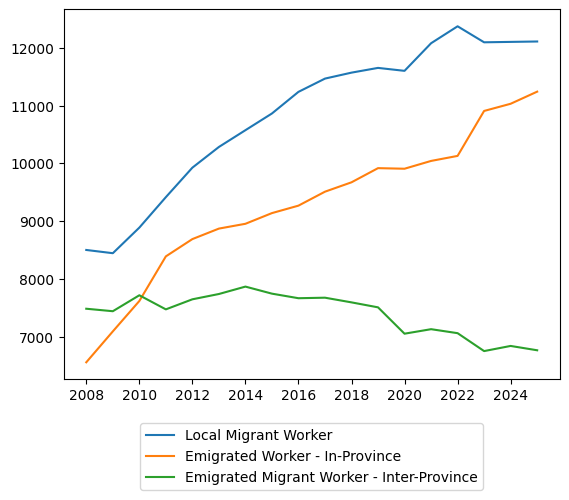

In [39]:
plt.plot(gen['Year'], gen['Local Migrant Worker Tot (10k)'], label = 'Local Migrant Worker')
plt.plot(gen['Year'], gen['Emigrated Worker Tot (10k)'] - gen['Emigrated Migrant Worker - Inter-Province (10k)'], label = 'Emigrated Worker - In-Province')
plt.plot(gen['Year'], gen['Emigrated Migrant Worker - Inter-Province (10k)'], label = 'Emigrated Migrant Worker - Inter-Province')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1))
plt.show()

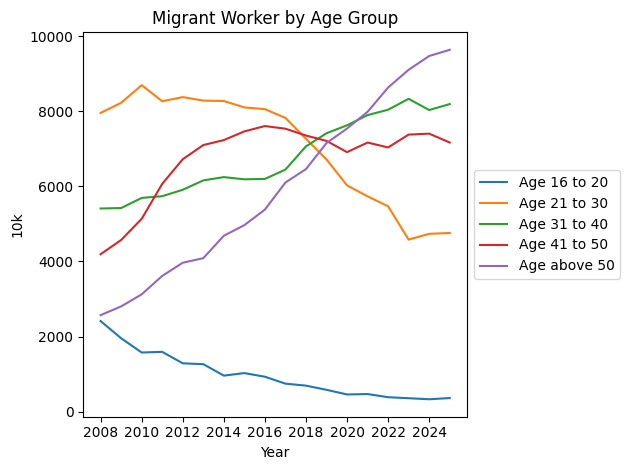

In [40]:
dem_agg = gen[['Year', 'Migrant Worker Tot (10k)']].merge(dem[['Year', 'Age 16 to 20 (%)', 'Age 21 to 30 (%)', 'Age 31 to 40 (%)','Age 41 to 50 (%)', 'Age above 50 (%)', 'Migrant Worker - Male (%)', 'Migrant Worker - Female (%)', 'Migrant Worker Education - Middle school or below (%)']], how='left')

plt.plot(dem_agg['Year'], dem_agg['Migrant Worker Tot (10k)']*dem_agg['Age 16 to 20 (%)']/100, label = 'Age 16 to 20')
plt.plot(dem_agg['Year'], dem_agg['Migrant Worker Tot (10k)']*dem_agg['Age 21 to 30 (%)']/100, label = 'Age 21 to 30')
plt.plot(dem_agg['Year'], dem_agg['Migrant Worker Tot (10k)']*dem_agg['Age 31 to 40 (%)']/100, label = 'Age 31 to 40')
plt.plot(dem_agg['Year'], dem_agg['Migrant Worker Tot (10k)']*dem_agg['Age 41 to 50 (%)']/100, label = 'Age 41 to 50')
plt.plot(dem_agg['Year'], dem_agg['Migrant Worker Tot (10k)']*dem_agg['Age above 50 (%)']/100, label = 'Age above 50')

plt.ylabel('10k')
plt.xlabel('Year')
plt.title('Migrant Worker by Age Group')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

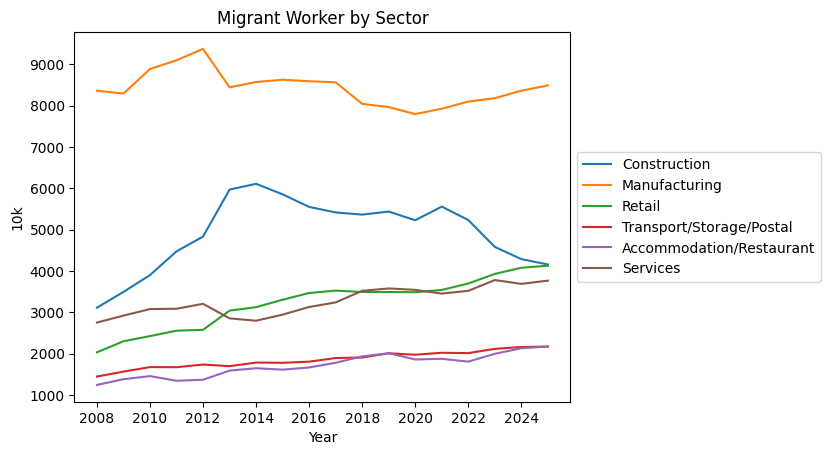

In [41]:
emp_agg = gen[['Year', 'Migrant Worker Tot (10k)']].merge(emp.drop(columns=['Average Monthly Salary (yuan)']), how='left')

plt.plot(emp_agg['Year'], emp_agg['Migrant Worker Tot (10k)']*emp_agg['Secondary Sector Employment (%) - Construction']/100, label = 'Construction')
plt.plot(emp_agg['Year'], emp_agg['Migrant Worker Tot (10k)']*emp_agg['Secondary Sector Employment (%) - Manufacturing']/100, label = 'Manufacturing')
plt.plot(emp_agg['Year'], emp_agg['Migrant Worker Tot (10k)']*emp_agg['Tertiary Sector Employment (%) - Retail']/100, label = 'Retail')
plt.plot(emp_agg['Year'], emp_agg['Migrant Worker Tot (10k)']*emp_agg['Tertiary Sector Employment (%) - Transport/Storage/Postal']/100, label = 'Transport/Storage/Postal')
plt.plot(emp_agg['Year'], emp_agg['Migrant Worker Tot (10k)']*emp_agg['Tertiary Sector Employment (%) - Accommodation/Restaurant']/100, label = 'Accommodation/Restaurant')
plt.plot(emp_agg['Year'], emp_agg['Migrant Worker Tot (10k)']*emp_agg['Tertiary Sector Employment (%) - Services']/100, label = 'Services')

plt.ylabel('10k')
plt.xlabel('Year')
plt.title('Migrant Worker by Sector')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [42]:
emp_agg.columns

Index(['Year', 'Migrant Worker Tot (10k)', 'Primary Sector Employment (%)',
       'Secondary Sector Employment (%)',
       'Secondary Sector Employment (%) - Manufacturing',
       'Secondary Sector Employment (%) - Construction',
       'Tertiary Sector Employment (%)',
       'Tertiary Sector Employment (%) - Retail',
       'Tertiary Sector Employment (%) - Transport/Storage/Postal',
       'Tertiary Sector Employment (%) - Accommodation/Restaurant',
       'Tertiary Sector Employment (%) - Services',
       'Average Monthly Salary (yuan) - Local',
       'Average Monthly Salary (yuan) - Emigrated',
       'Average Monthly Salary (yuan) - in Eastern (including Liaoning till 2016)',
       'Average Monthly Salary (yuan) - in Central (including Heilongjiang and Jilin till 2016)',
       'Average Monthly Salary (yuan) - in Western',
       'Average Monthly Salary (yuan) - in Northeastern',
       'Average Monthly Salary (yuan) - Manufacturing',
       'Average Monthly Salary (yuan) -

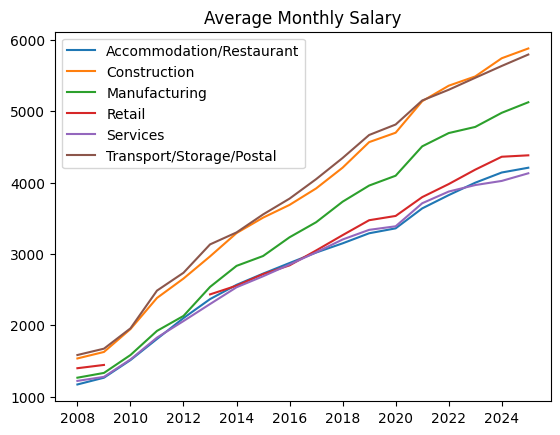

In [43]:
plt.plot(emp_agg['Year'], emp_agg['Average Monthly Salary (yuan) - Accommodation/Restaurant'], label = 'Accommodation/Restaurant')
plt.plot(emp_agg['Year'], emp_agg['Average Monthly Salary (yuan) - Construction'], label = 'Construction')
plt.plot(emp_agg['Year'], emp_agg['Average Monthly Salary (yuan) - Manufacturing'], label = 'Manufacturing')
plt.plot(emp_agg['Year'], emp_agg['Average Monthly Salary (yuan) - Retail'], label = 'Retail')
plt.plot(emp_agg['Year'], emp_agg['Average Monthly Salary (yuan) - Services'], label = 'Services')
plt.plot(emp_agg['Year'], emp_agg['Average Monthly Salary (yuan) - Transport/Storage/Postal'], label = 'Transport/Storage/Postal')

plt.title('Average Monthly Salary')
plt.legend()
plt.show()

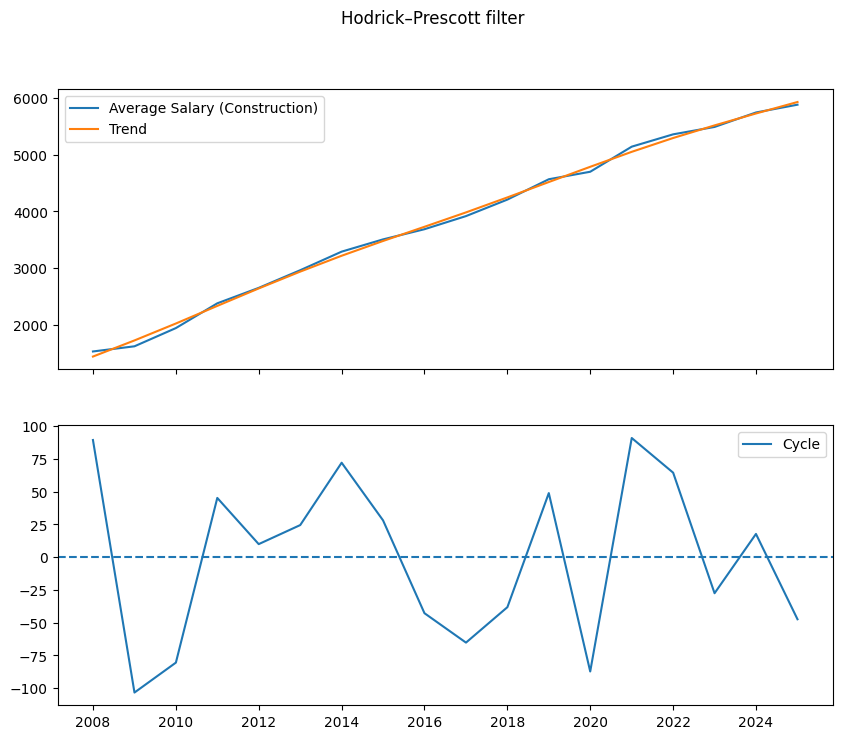

In [81]:
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter

emp_agg_ts = emp_agg[['Year', 'Average Monthly Salary (yuan) - Construction']].copy()
emp_agg_ts.set_index('Year', inplace=True)

cycle, trend = hpfilter(emp_agg_ts['Average Monthly Salary (yuan) - Construction'], lamb=6.25)
construction_decomp = emp_agg_ts[['Average Monthly Salary (yuan) - Construction']]
construction_decomp['cycle'] = cycle
construction_decomp['trend'] = trend

fig, axs = plt.subplots(2, 1, figsize=(10,8),sharex=True)

axs[0].plot(construction_decomp['Average Monthly Salary (yuan) - Construction'], label='Average Salary (Construction)')
axs[0].plot(construction_decomp['trend'], label='Trend')
axs[0].legend()

axs[1].plot(construction_decomp['cycle'], label='Cycle')
axs[1].axhline(y=0, linestyle='--')
axs[1].legend()

plt.suptitle('Hodrick–Prescott filter')
plt.show()